<a href="https://colab.research.google.com/github/SohailVibeCoder/IB9AU---GenAI/blob/main/Task_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#The Local "Code Agent" (Qwen 2.5-Coder-3B-Instruct)
⚠️ **Important Colab Note: Ensure your runtime is set to T4 GPU (Runtime > Change runtime type > T4 GPU). This model fits tightly in the 16GB VRAM, so do not run other large models in the same session.**

Before we can run our local Code Agent, we need to install the necessary Python libraries. `smolagents` is our framework for building agents, while `transformers`, `accelerate`, and `bitsandbytes` are crucial for efficiently loading and running large language models on a GPU. `yfinance`, `seaborn`, and `matplotlib` are data science libraries the agent will use for financial data analysis and visualization.

In [ ]:
# ==========================================
# Install Dependencies
# ==========================================
# We need 'accelerate' and 'bitsandbytes' to load the model efficiently on the GPU.
# Added 'duckduckgo_search' to enable web search capabilities for the agent.
!pip install -q smolagents transformers accelerate bitsandbytes yfinance seaborn matplotlib duckduckgo_search


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 90.6 MB/s eta 0:00:00


Now we'll load the `Qwen 2.5 Coder 3B` model. This model is specifically designed for code generation tasks. We're using `TransformersModel` from `smolagents` to load it. `device_map='auto'` ensures the model automatically utilizes the available T4 GPU, and `torch_dtype=torch.float16` reduces memory footprint by using half-precision floating-point numbers. `max_new_tokens` is set to allow for longer code outputs.

In [ ]:
# ==========================================
# Load the 3B Model (Lightweight & Fast)
# ==========================================
from smolagents import CodeAgent, TransformersModel
import torch

print("⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...")

# We use the 3B-Instruct model.
# device_map="auto" finds the Colab GPU.
# torch_dtype=torch.float16 cuts memory usage in half.
model = TransformersModel(
    model_id="Qwen/Qwen2.5-Coder-3B-Instruct",
    device_map="auto",
    torch_dtype=torch.float16,
    max_new_tokens=2048  # Give it space to write longer scripts
)

print("✅ 3B Model loaded on GPU! Ready for coding.")

⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ 3B Model loaded on GPU! Ready for coding.


With the model loaded, we can now initialize our `CodeAgent`. We provide it with the loaded `model` and specify `additional_authorized_imports`. This list tells the agent which Python libraries it is allowed to use when generating and executing code. Crucially, we don't give it predefined tools; instead, it writes its own code using these authorized libraries, making it highly flexible.

In [ ]:
# ==========================================
# Initialize the Agent
# ==========================================

# We authorize the agent to use specific data science libraries, and now also a web search library.
agent = CodeAgent(
    tools=[], # We don't need pre-made tools; the agent writes its own code.
    model=model,
    max_steps=3,
    additional_authorized_imports=[
        "yfinance",
        "pandas",
        "numpy",
        "seaborn",
        "matplotlib.pyplot",
        "duckduckgo_search" # Added for web search capabilities
    ]
)


#Required Task 17

**The Assignment:** You are a Quantitative Analyst. Your boss wants to know which sector has performed better this year on a risk-adjusted basis: Big Tech or Big Banks.

**Task:** Write a prompt for your Local smolagents (Qwen 3B) agent to perform the following steps autonomously:

**Data Ingestion:** Download daily closing prices for the last 180 days for a Tech Portfolio (NVDA, AAPL, MSFT) and a Bank Portfolio (JPM, BAC, C).

**Financial Math:**

*   Calculate the Daily Returns for each stock.
*   Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev of Daily Returns * sqrt(252)).

**Visualization:**

* Create a Bar Chart comparing the Sharpe Ratios of all 6 companies.

* Color code the bars: Green for Tech, Blue for Banks.

**Output:** Save the chart as `sharpe_comparison.png`.


🤖 Agent is coding the Sharpe Ratio comparison...


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 1. Download daily closing prices for the last 180 days for these 6 stocks using yfinance:                       │
│    - Tech Portfolio: NVDA, AAPL, MSFT                                                                           │
│    - Bank Portfolio: JPM, BAC, C                                                                                │
│                                                                                                                 │
│ 2. Calculate the daily percentage returns for each stock using pct_change().                                    │
│                                                                                                                 │
│ 3. Calculate the annualized Sharpe Ratio for each stock assuming a risk-free rate of 0:                         │
│    Sharpe Ratio = (Mean Daily Return / Std Dev of Daily Returns) * sqrt(252)                                    │
│                                                                                                                 │
│ 4. Create a bar chart comparing the Sharpe Ratios of all 6 companies using matplotlib:                          │
│    - Color the Tech stocks (NVDA, AAPL, MSFT) in green.                                                         │
│    - Color the Bank stocks (JPM, BAC, C) in blue.                                                               │
│    - Add a title: 'Annualized Sharpe Ratio: Big Tech vs Big Banks'                                              │
│    - Label the x-axis with stock tickers and the y-axis as 'Sharpe Ratio'.                                      │
│    - Add the Sharpe Ratio value on top of each bar.                                                             │
│                                                                                                                 │
│ 5. Save the chart as 'sharpe_comparison.png'.                                                                   │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import matplotlib.pyplot as plt                                                                                  
  import numpy as np                                                                                               
                                                                                                                   
  # Step 1: Download daily closing prices for the last 180 days for the specified stocks                           
  tech_stocks = ['NVDA', 'AAPL', 'MSFT']                                                                           
  bank_stocks = ['JPM', 'BAC', 'C']                                                                                
                                                                                                                   
  tech_data = yf.download(tech_stocks, period='180d')                                                              
  bank_data = yf.download(bank_stocks, period='180d')                                                              
                                                                                                                   
  # Step 2: Calculate the daily percentage returns for each stock                                                  
  tech_returns = tech_data['Close'].pct_change()                                                                   
  bank_returns = bank_data['Close'].pct_change()                                                                   
                                                                                                                   
  # Step 3: Calculate the annualized Sharpe Ratio for each stock                                                   
  risk_free_rate = 0                                                                                               
  num_days_in_year = 252                                                                                           
                                                                                                                   
  tech_sharpe_ratios = (tech_returns.mean() / tech_returns.std()) * np.sqrt(num_days_in_year)                      
  bank_sharpe_ratios = (bank_returns.mean() / bank_returns.std()) * np.sqrt(num_days_in_year)                      
                                                                                                                   
  # Step 4: Create a bar chart comparing the Sharpe Ratios of all 6 companies                                      
  plt.figure(figsize=(10, 6))                                                                                      
  bars = plt.bar(['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C'], [tech_sharpe_ratios[0], tech_sharpe_ratios[1],       
  tech_sharpe_ratios[2],                                                                                           
                                                      bank_sharpe_ratios[0], bank_sharpe_ratios[1],                
  bank_sharpe_ratios[2]], color=['green', 'green', 'green', 'blue', 'blue', 'blue'])                               
                                                                                                                   
  # Add title and labels                                                                                           
  plt[38;2;255;70;137;48;2;

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:931: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return value[index]


Final answer: Chart saved as 'sharpe_comparison.png'

[Step 1: Duration 48.19 seconds| Input tokens: 2,282 | Output tokens: 688]

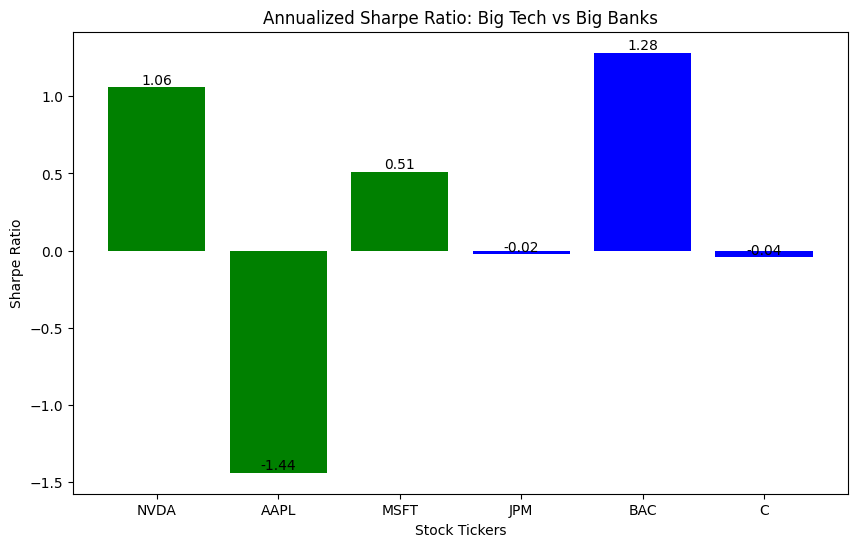

In [ ]:
# ==========================================
# Task 17: Sharpe Ratio Comparison - Big Tech vs Big Banks
# ==========================================

task_sharpe = """
1. Download daily closing prices for the last 180 days for these 6 stocks using yfinance:
   - Tech Portfolio: NVDA, AAPL, MSFT
   - Bank Portfolio: JPM, BAC, C

2. Calculate the daily percentage returns for each stock using pct_change().

3. Calculate the annualized Sharpe Ratio for each stock assuming a risk-free rate of 0:
   Sharpe Ratio = (Mean Daily Return / Std Dev of Daily Returns) * sqrt(252)

4. Create a bar chart comparing the Sharpe Ratios of all 6 companies using matplotlib:
   - Color the Tech stocks (NVDA, AAPL, MSFT) in green.
   - Color the Bank stocks (JPM, BAC, C) in blue.
   - Add a title: 'Annualized Sharpe Ratio: Big Tech vs Big Banks'
   - Label the x-axis with stock tickers and the y-axis as 'Sharpe Ratio'.
   - Add the Sharpe Ratio value on top of each bar.

5. Save the chart as 'sharpe_comparison.png'.
"""

print("🤖 Agent is coding the Sharpe Ratio comparison...")
result = agent.run(task_sharpe, stream=False)

In [ ]:
print(result)

Chart saved as 'sharpe_comparison.png'



📊 Displaying Sharpe Ratio Comparison Chart:


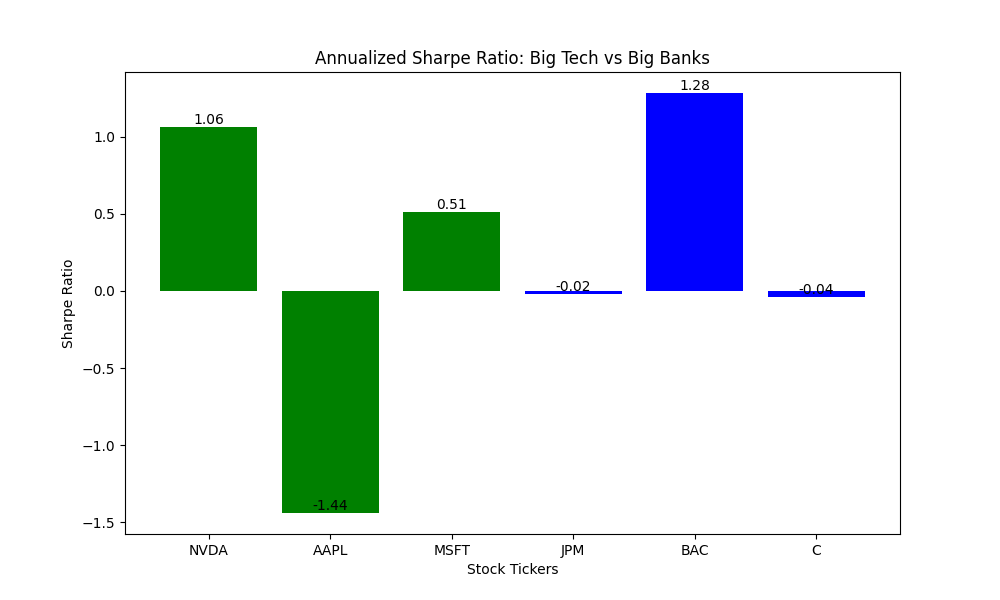

In [ ]:
# ==========================================
# Display the Sharpe Ratio Chart
# ==========================================
import IPython
import os

if os.path.exists("sharpe_comparison.png"):
    print("\n📊 Displaying Sharpe Ratio Comparison Chart:")
    IPython.display.display(IPython.display.Image("sharpe_comparison.png"))
else:
    print("⚠️ No image file found. Check the agent's output logs above for errors.")